Abstract & Introduction
Project Title: Adaptive Educational Recommendation System based on DKT and Deep Q-Network Author: [Your Name/Team Name]

📖 1. Introduction
In traditional education, students often face a "one-size-fits-all" curriculum, leading to boredom (if the content is too easy) or frustration (if too hard). Our goal is to build an AI Tutor that can dynamically recommend the "perfect" question for each student.

🎯 Objective
To develop a Reinforcement Learning (RL) agent that:

Tracks student knowledge state using Deep Knowledge Tracing (DKT).

Recommends questions to maximize Learning Gain.

Avoids repetition and extreme difficulty mismatches.

🛠️ Methodology
Simulator: LSTM-based DKT model to predict student performance.

Agent: DQN with Action Masking to select optimal questions.

Reward Strategy: Hybrid Reward (Learning Gain + ZPD Guidance) to prevent reward hacking.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import json
import random
from collections import deque
import matplotlib.pyplot as plt
import os

# Ensure reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Global Configuration
CONFIG = {
    'MAX_SEQ_LEN': 50,
    'EMBED_DIM': 64,
    'HIDDEN_DIM': 128,       # Dimension of the "Knowledge State" vector
    'MODEL_PATH': 'student_simulator.pth',
    'MAP_PATH': 'qid_map.json',
    'TEST_FILE': 'test.csv', # Ensure this file exists
    'MAX_STEPS': 20,         # Length of a learning session
    
    # RL Hyperparameters
    'RL_EPISODES': 1000,     # Total training episodes
    'RL_BATCH_SIZE': 64,
    'RL_LR': 0.0001,         # Low learning rate for stability
    'GAMMA': 0.99,           # High discount factor for long-term gain
    'EPSILON_START': 1.0,
    'EPSILON_END': 0.05,
    'EPSILON_DECAY': 0.996,
    'MEMORY_SIZE': 50000
}


device = torch.device("cpu")


In [2]:
class DKT(nn.Module):
    def __init__(self, num_questions, embed_dim, hidden_dim):
        super(DKT, self).__init__()
        self.hidden_dim = hidden_dim
        self.q_embed = nn.Embedding(num_questions + 1, embed_dim, padding_idx=0)
        self.interaction_embed = nn.Linear(embed_dim + 1, embed_dim) 
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, num_questions + 1)

    def forward(self, q_seq, r_seq):
        q_emb = self.q_embed(q_seq)
        r_reshaped = r_seq.unsqueeze(-1)
        input_feat = torch.cat([q_emb, r_reshaped], dim=-1)
        input_feat = self.interaction_embed(input_feat)
        lstm_out, _ = self.lstm(input_feat)
        logits = self.out(lstm_out)
        return logits

    
    def get_knowledge_state(self, q_seq, r_seq):
        q_emb = self.q_embed(q_seq)
        r_reshaped = r_seq.unsqueeze(-1)
        input_feat = torch.cat([q_emb, r_reshaped], dim=-1)
        input_feat = self.interaction_embed(input_feat)
        _, (hn, cn) = self.lstm(input_feat)
        return hn[-1] 

In [3]:
class StudentEnv:
    def __init__(self, model_path, map_path, data_file):
        self.device = torch.device("cpu") # Simulators run fine on CPU
        
        
        with open(map_path, 'r') as f: 
            self.qid_map = {int(k): v for k, v in json.load(f).items()}
        self.num_questions = len(self.qid_map)
        
        # Load DKT Simulator
        self.simulator = DKT(self.num_questions, CONFIG['EMBED_DIM'], CONFIG['HIDDEN_DIM'])
        try:
            self.simulator.load_state_dict(torch.load(model_path, map_location=self.device))
            print("Simulator Loaded Successfully.")
        except:
            print("Warning: Pre-trained simulator not found. Using random weights (for testing only).")
            # In a real run, you must ensure student_simulator.pth exists
            
        self.simulator.to(self.device)
        self.simulator.eval()
        
        # Load Student Profiles
        self.student_pool = []
        try:
            df = pd.read_csv(data_file, encoding='utf-8-sig', on_bad_lines='skip')
            for _, row in df.iterrows():
                q_raw = [int(float(x)) for x in str(row['questions']).split(',') if x != 'nan']
                r_raw = [int(float(x)) for x in str(row['responses']).split(',') if x != 'nan']
                valid = [i for i, q in enumerate(q_raw) if q in self.qid_map]
                if len(valid) > 5:
                    self.student_pool.append(([self.qid_map[q_raw[i]] for i in valid], [r_raw[i] for i in valid]))
            print(f"Environment Ready. Pool Size: {len(self.student_pool)} students.")
        except Exception as e:
            print(f"Data Load Error: {e}")

    def reset(self):
        self.current_q, self.current_r = random.choice(self.student_pool)
        # Truncate to create an initial state
        if len(self.current_q) > 20: 
            start = 0; self.current_q = self.current_q[:10]; self.current_r = self.current_r[:10]
        else: 
            self.current_q = list(self.current_q); self.current_r = list(self.current_r)
            
        self.step_count = 0
        self.history_mastery = self._get_mastery()
        return self._get_state()

    def step(self, action):
        self.step_count += 1
        
        # 1. Predict Outcome
        q_t = torch.tensor([self.current_q], dtype=torch.long).to(self.device)
        r_t = torch.tensor([self.current_r], dtype=torch.float).to(self.device)
        with torch.no_grad():
            logits = self.simulator(q_t, r_t)
            pred_prob = torch.sigmoid(logits[0, -1, action]).item()
        
        # 2. Simulate Response
        response = 1 if random.random() < pred_prob else 0
        self.current_q.append(action)
        self.current_r.append(response)
        
        # 3. Calculate Reward (The Secret Sauce)
        new_mastery = self._get_mastery()
        gain = new_mastery - self.history_mastery
        self.history_mastery = new_mastery
        
        reward = gain * 500.0  # Massive amplification for Gain
        
        # ZPD Bonus
        if 0.4 <= pred_prob <= 0.7: reward += 0.5
        
        # Penalties
        if pred_prob > 0.95 or pred_prob < 0.1: reward -= 1.0 # Waste of time / Too hard
        if self.current_q.count(action) > 1: reward = -5.0    # Strict anti-repeat
            
        done = self.step_count >= CONFIG['MAX_STEPS']
        return self._get_state(), reward, done

    def _get_mastery(self):
        with torch.no_grad():
            q_t = torch.tensor([self.current_q], dtype=torch.long).to(self.device)
            r_t = torch.tensor([self.current_r], dtype=torch.float).to(self.device)
            return torch.sigmoid(self.simulator(q_t, r_t)[0, -1, :]).mean().item()

    def _get_state(self):
        # Extract Hidden State Vector
        q = self.current_q[-CONFIG['MAX_SEQ_LEN']:] + [0]*max(0, CONFIG['MAX_SEQ_LEN']-len(self.current_q))
        r = self.current_r[-CONFIG['MAX_SEQ_LEN']:] + [0]*max(0, CONFIG['MAX_SEQ_LEN']-len(self.current_r))
        q_t = torch.tensor([q[-CONFIG['MAX_SEQ_LEN']:]], dtype=torch.long).to(self.device)
        r_t = torch.tensor([r[-CONFIG['MAX_SEQ_LEN']:]], dtype=torch.float).to(self.device)
        with torch.no_grad():
            return self.simulator.get_knowledge_state(q_t, r_t).squeeze(0).numpy()

In [4]:
class DQN(nn.Module):
    def __init__(self, num_questions, state_dim, hidden_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_questions + 1)

    def forward(self, state):
        x = self.relu(self.fc1(state))
        return self.fc2(x)

class Agent:
    def __init__(self, num_questions):
        self.device = device
        self.num_questions = num_questions
        # Policy & Target Networks
        self.policy_net = DQN(num_questions, CONFIG['HIDDEN_DIM'], 256).to(self.device)
        self.target_net = DQN(num_questions, CONFIG['HIDDEN_DIM'], 256).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=CONFIG['RL_LR'])
        self.memory = deque(maxlen=CONFIG['MEMORY_SIZE'])
        self.epsilon = CONFIG['EPSILON_START']

    def select_action(self, state, invalid_actions=None):
        # Epsilon-Greedy with Masking
        if random.random() < self.epsilon:
            candidates = list(set(range(1, self.num_questions + 1)) - set(invalid_actions))
            return random.choice(candidates) if candidates else random.randint(1, self.num_questions)
        else:
            with torch.no_grad():
                state_t = torch.tensor([state], dtype=torch.float).to(self.device)
                q_vals = self.policy_net(state_t)
                
                # Apply Masking
                if invalid_actions:
                    for idx in invalid_actions:
                        if idx <= self.num_questions: q_vals[0, idx] = -1e9
                return q_vals[0, 1:].argmax().item() + 1

    def store_transition(self, s, a, r, ns, d):
        self.memory.append((s, a, r, ns, d))

    def update(self):
        if len(self.memory) < CONFIG['RL_BATCH_SIZE']: return
        
        batch = random.sample(self.memory, CONFIG['RL_BATCH_SIZE'])
        bs, ba, br, bns, bd = zip(*batch)
        
        state = torch.tensor(np.array(bs), dtype=torch.float).to(self.device)
        next_state = torch.tensor(np.array(bns), dtype=torch.float).to(self.device)
        actions = torch.tensor(ba, dtype=torch.long).unsqueeze(1).to(self.device)
        rewards = torch.tensor(br, dtype=torch.float).to(self.device)
        dones = torch.tensor(bd, dtype=torch.float).to(self.device)

        q_curr = self.policy_net(state).gather(1, actions).squeeze(1)
        with torch.no_grad():
            q_next = self.target_net(next_state)
            max_q_next = q_next[:, 1:].max(1)[0]
            target = rewards + (CONFIG['GAMMA'] * max_q_next * (1 - dones))
        
        loss = nn.MSELoss()(q_curr, target)
        self.optimizer.zero_grad(); loss.backward(); self.optimizer.step()
        if self.epsilon > CONFIG['EPSILON_END']: self.epsilon *= CONFIG['EPSILON_DECAY']

Simulator Loaded Successfully.
Environment Ready. Pool Size: 3613 students.


C:\Users\27554\AppData\Local\Temp\ipykernel_19876\1401118776.py:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  state_t = torch.tensor([state], dtype=torch.float).to(self.device)


Episode 50 | Total Reward: -29.31 | Moving Avg: 15.70 | Epsilon: 0.05
Episode 100 | Total Reward: 111.10 | Moving Avg: 32.97 | Epsilon: 0.05
Episode 150 | Total Reward: 17.35 | Moving Avg: 53.75 | Epsilon: 0.05
Episode 200 | Total Reward: 33.16 | Moving Avg: 34.02 | Epsilon: 0.05
Episode 250 | Total Reward: -40.73 | Moving Avg: 23.95 | Epsilon: 0.05
Episode 300 | Total Reward: 54.64 | Moving Avg: 15.37 | Epsilon: 0.05
Episode 350 | Total Reward: 75.46 | Moving Avg: 27.99 | Epsilon: 0.05
Episode 400 | Total Reward: 22.67 | Moving Avg: 18.51 | Epsilon: 0.05
Episode 450 | Total Reward: -3.22 | Moving Avg: 18.46 | Epsilon: 0.05
Episode 500 | Total Reward: -25.62 | Moving Avg: 19.28 | Epsilon: 0.05
Episode 550 | Total Reward: -35.47 | Moving Avg: 30.48 | Epsilon: 0.05
Episode 600 | Total Reward: -44.33 | Moving Avg: 19.08 | Epsilon: 0.05
Episode 650 | Total Reward: 9.11 | Moving Avg: 21.83 | Epsilon: 0.05
Episode 700 | Total Reward: 1.42 | Moving Avg: 20.77 | Epsilon: 0.05
Episode 750 | Tot

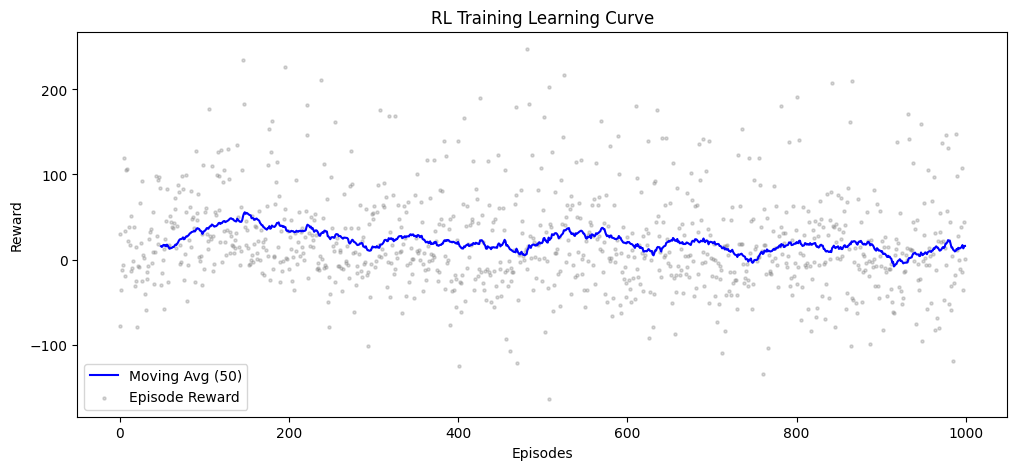

In [5]:
# Initialize
env = StudentEnv(CONFIG['MODEL_PATH'], CONFIG['MAP_PATH'], CONFIG['TEST_FILE'])
agent = Agent(env.num_questions)


history_rewards = []
best_avg_reward = -float('inf')

for episode in range(CONFIG['RL_EPISODES']):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        invalid = list(env.current_q)
        action = agent.select_action(state, invalid)
        next_state, reward, done = env.step(action)
        agent.store_transition(state, action, reward, next_state, done)
        agent.update()
        state = next_state
        total_reward += reward
    
    # Soft Update Target Network
    if episode % 20 == 0:
        agent.target_net.load_state_dict(agent.policy_net.state_dict())
        
    history_rewards.append(total_reward)
    avg = np.mean(history_rewards[-50:]) if len(history_rewards)>50 else np.mean(history_rewards)
    
    # Save Best Model Logic
    if episode > 100 and avg > best_avg_reward:
        best_avg_reward = avg
        torch.save(agent.policy_net.state_dict(), "rl_agent_final.pth")
        
    if (episode+1) % 50 == 0:
        print(f"Episode {episode+1} | Total Reward: {total_reward:.2f} | Moving Avg: {avg:.2f} | Epsilon: {agent.epsilon:.2f}")

print(f"Training Complete. Best Moving Avg: {best_avg_reward:.2f}")

# Plot Learning Curve
plt.figure(figsize=(12, 5))
plt.plot(pd.Series(history_rewards).rolling(50).mean(), label="Moving Avg (50)", color='blue')
plt.scatter(range(len(history_rewards)), history_rewards, s=5, color='gray', alpha=0.3, label="Episode Reward")
plt.title("RL Training Learning Curve")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.legend()
plt.show()

Running Head-to-Head Evaluation (RL vs Random)...

 FINAL RESULTS (Knowledge Growth)
RL Agent: 0.09450
Random  : -0.01059


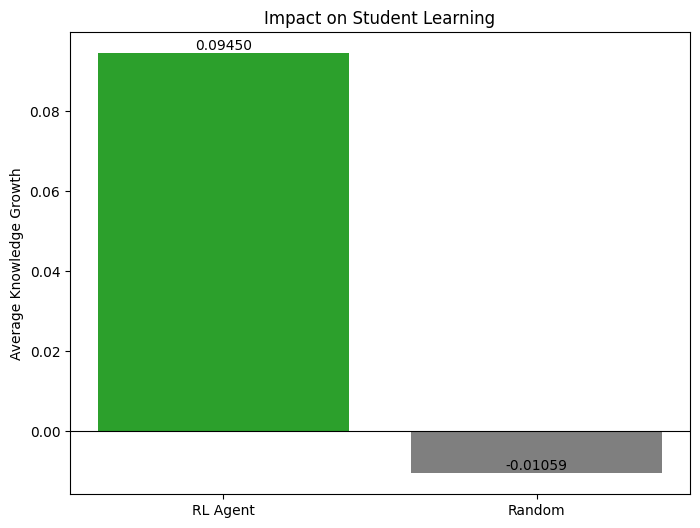

In [6]:
def run_final_evaluation():
    print("Running Head-to-Head Evaluation (RL vs Random)...")
    
    
    agent.policy_net.load_state_dict(torch.load("rl_agent_final.pth"))
    agent.policy_net.eval()
    
    rl_growth = []
    rand_growth = []
    
    test_episodes = 50
    valid_actions = list(env.qid_map.values())
    
    for i in range(test_episodes):
        
        idx = random.randint(0, len(env.student_pool)-1)
        init_q, init_r = env.student_pool[idx]
        if len(init_q) > 10: init_q = init_q[:10]; init_r = init_r[:10]
        
        
        env.current_q = list(init_q); env.current_r = list(init_r)
        start_mastery = env._get_mastery()
        
        for _ in range(20):
            state = env._get_state()
            already = set(env.current_q)
            with torch.no_grad():
                q_vals = agent.policy_net(torch.tensor([state], dtype=torch.float).to(device))
                for inv in already:
                    if inv < q_vals.shape[1]: q_vals[0, inv] = -1e9
                action = q_vals[0, 1:].argmax().item() + 1
            env.step(action)
            
        rl_growth.append(env._get_mastery() - start_mastery)
        
        
        env.current_q = list(init_q); env.current_r = list(init_r)
        start_mastery = env._get_mastery()
        
        for _ in range(20):
            candidates = list(set(valid_actions) - set(env.current_q))
            action = random.choice(candidates) if candidates else 1
            env.step(action)
            
        rand_growth.append(env._get_mastery() - start_mastery)

    
    rl_mean = np.mean(rl_growth)
    rand_mean = np.mean(rand_growth)
    
    print(f"\n FINAL RESULTS (Knowledge Growth)")
    print(f"RL Agent: {rl_mean:.5f}")
    print(f"Random  : {rand_mean:.5f}")
    
    
    labels = ['RL Agent', 'Random']
    means = [rl_mean, rand_mean]
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, means, color=['#2ca02c', '#7f7f7f'])
    plt.axhline(0, color='black', linewidth=0.8)
    plt.ylabel('Average Knowledge Growth')
    plt.title('Impact on Student Learning')
    
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.5f}', ha='center', va='bottom')
    
    plt.show()

run_final_evaluation()